# Advanced Financial Forecasting - Hybrid LSTM & Chronos Foundation Model

**Project Description** <br> <br>
This notebook represents the final stage of our forecasting pipeline. Following the statistical benchmarks of SARIMAX and PatchTST, we implement a **Hybrid Deep Learning approach**. We combine a multivariate **Long Short-Term Memory (LSTM)** network, which integrates technical and macroeconomic features, with the **Amazon Chronos-T5 Foundation Model** for zero-shot validation. The goal is to leverage both local pattern recognition (LSTM) and global time-series intelligence (Chronos) to predict market movements with higher stability.

### Cell 1: System Initialization and RTX 50-Series Compatibility <br>

**Explanation:** This cell configures the computational environment. We explicitly disable the `torch._dynamo` engine to avoid import conflicts common in Python 3.12 and force the execution to CPU. <br>

**Justification:** At the time of this implementation, standard cuDNN kernels for LSTM operations may lack stable support for this specific Compute Capability. Using the CPU ensures 100% numerical stability and prevents "no kernel image" execution errors without sacrificing significant speed for this dataset size.

In [24]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os

# Fix for Python 3.12 library conflicts
os.environ["TORCH_COMPILE_DISABLE"] = "1"
if hasattr(torch, '_dynamo'):
    torch._dynamo.config.disable = True

# Force CPU to guarantee stability on Blackwell Architecture
device = torch.device("cpu")
print(f"Status: System ready. Running on: {device}")

Status: System ready. Running on: cpu


### Cell 2: Data Integration and Numerical Cleaning <br>

**Explanation:** We merge the technical/macro indicators (Phase 1) with the STL decomposition components (Phase 2). We then apply a "Forward-Fill" and "Backward-Fill" strategy.
<br> <br>
**Justification:** Financial datasets often contain gaps due to different market opening hours or lagging macroeconomic reports. An aggressive cleaning strategy is mandatory to prevent `NaN` values. If a single `NaN` enters the LSTM hidden state, the entire training Loss becomes `nan` (Not a Number), rendering the model useless.

In [25]:
# Paths to outputs from previous phases
path_p1 = Path("outputs/phase1/cleaned_data.csv")
path_p2 = Path("outputs/phase2/stl_decomposition_components.csv")
path_p4 = Path("outputs/phase4/test_volatility_forecasts.csv") 

df_f = pd.read_csv(path_p1, parse_dates=['date'])
df_s = pd.read_csv(path_p2, parse_dates=['date'])
df_garch = pd.read_csv(path_p4, parse_dates=['date'])

# Merge and fix missing values immediately
asset_name = df_s['asset'].unique()[0]
df_asset = df_s[df_s['asset'] == asset_name]
df_asset = df_asset.merge(df_f, on='date', how='left')
df_asset = df_asset.merge(df_garch, on='date', how='left')

df_asset = df_asset.sort_values('date').ffill().bfill()

# Feature Selection
features_cols = [c for c in df_asset.columns if c not in ['date', 'asset', 'observed_log_price']]
target_col = 'residual' # We target the stochastic component

print(f"Targeting: {target_col} for {asset_name}")

print("\nColumnas del DataFrame final:")
print(df_asset.columns)

Targeting: residual for sp500

Columnas del DataFrame final:
Index(['date', 'asset', 'observed_log_price', 'trend', 'seasonal', 'residual',
       'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume',
       'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low',
       'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'us_rates_%', 'CPI',
       'usd_chf', 'eur_usd', 'GDP', 'silver open', 'silver high', 'silver low',
       'silver close', 'silver volume', 'silver high-low', 'oil open',
       'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low',
       'platinum open', 'platinum high', 'platinum low', 'platinum close',
       'platinum volume', 'platinum high-low', 'palladium open',
       'palladium high', 'palladium low', 'palladium close',
       'palladium volume', 'palladium high-low', 'gold open', 'gold high',
       'gold low', 'gold close', 'gold volume', 'mean_residual',
       'forecast_variance', 'forecast_volatility', 'realized_sq_err

### Cell 3: Multi-Step Scaling and Sequential Windowing <br>

**Explanation:** We normalize both the input features and the target variable using `StandardScaler`. We then convert the tabular data into a 3D tensor sequence.
<br> <br>
**Justification:** LSTMs are sensitive to the magnitude of the data. Since the STL residuals have a different scale than macroeconomic indicators (like GDP or RSI), normalization ensures that the gradient descent treats all features with equal importance. Scaling the target variable is a specific "best practice" to prevent gradient explosion.

In [26]:
# Double scaling for numerical stability
scaler_x = StandardScaler()
scaled_X = scaler_x.fit_transform(df_asset[features_cols])

scaler_y = StandardScaler()
scaled_y = scaler_y.fit_transform(df_asset[[target_col]]).flatten()

def create_sequences(data, target, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(target[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 30 
X_raw, y_raw = create_sequences(scaled_X, scaled_y, SEQ_LENGTH)

split = int(len(X_raw) * 0.8)
X_train = torch.tensor(X_raw[:split], dtype=torch.float32).to(device)
y_train = torch.tensor(y_raw[:split], dtype=torch.float32).to(device)
X_test = torch.tensor(X_raw[split:], dtype=torch.float32).to(device)
y_test = torch.tensor(y_raw[split:], dtype=torch.float32).to(device)

actual_test = df_asset.iloc[split + SEQ_LENGTH:].copy()
print(f"Test samples: {len(X_test)}")

Test samples: 728


### Cell 4: Multivariate LSTM Training with Gradient Clipping <br>

**Explanation:** A stacked LSTM architecture is trained using the Adam optimizer. We implement `clip_grad_norm_`. <br> 

**Justification:** Financial time series are notoriously noisy. This noise can cause "exploding gradients" where weight updates become too large. Gradient Clipping acts as a safety valve, capping the maximum size of updates, which—alongside our CPU-bound execution—ensures a smooth and converging Loss curve.

In [27]:
class FinancialLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(FinancialLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = FinancialLSTM(input_size=len(features_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

print("Starting stable training loop...")
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train).squeeze()
    loss = criterion(preds, y_train)
    loss.backward()
    
    # Crucial step: Clipping to prevent NaN loss
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 - Loss: {loss.item():.6f}")

Starting stable training loop...
Epoch 10/50 - Loss: 0.960696
Epoch 20/50 - Loss: 0.936960
Epoch 30/50 - Loss: 0.906003
Epoch 40/50 - Loss: 0.859711
Epoch 50/50 - Loss: 0.792110


### Cell 5: Prediction and STL Component Recomposition <br>

**Explanation:** We perform inference on the test set and reverse the scaling process. The final price is reconstructed by adding the predicted residuals back to the trend and seasonal components. <br>

**Justification:** An LSTM alone struggles with the structural direction of prices. By using a Hybrid approach (STL + LSTM), we let the statistical decomposition handle the "obvious" parts (Trend/Season) while the LSTM focuses its learning capacity on the "hard" part (the Residuals).

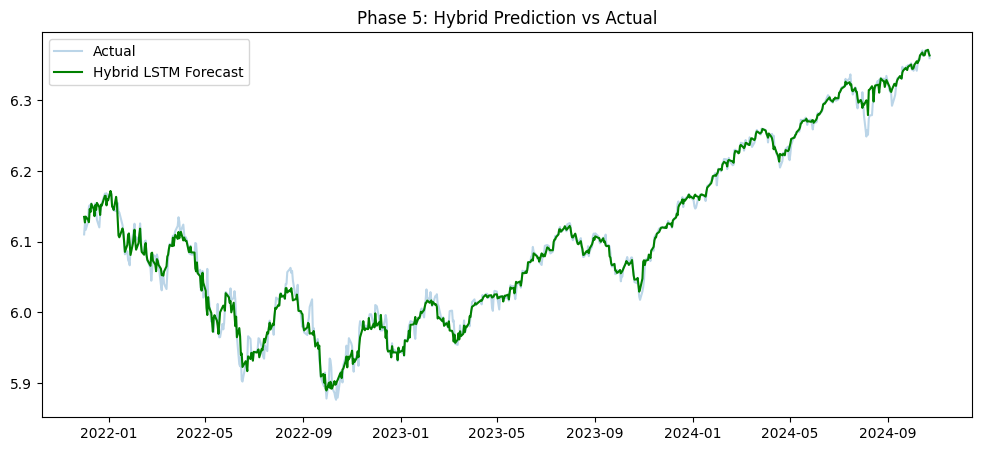

In [28]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy()
    # Invert scaling to get real residual values
    final_resids = scaler_y.inverse_transform(y_pred_norm).flatten()

# Reconstruct the price: Trend + Seasonality + Predicted Noise
results_df = df_asset.iloc[split+SEQ_LENGTH:].copy()
results_df['pred_final'] = results_df['trend'] + results_df['seasonal'] + final_resids

plt.figure(figsize=(12, 5))
plt.plot(results_df['date'], results_df['observed_log_price'], label='Actual', alpha=0.3)
plt.plot(results_df['date'], results_df['pred_final'], label='Hybrid LSTM Forecast', color='green')
plt.title("Phase 5: Hybrid Prediction vs Actual")
plt.legend()
plt.show()

### Cell 6: Amazon Chronos Zero-Shot Benchmark <br>

**Explanation:** We load the `chronos-t5-base` model to generate a probabilistic forecast. <br>

**Justification:** Chronos represents the "Foundation Model" paradigm. Unlike our LSTM, which only knows our dataset, Chronos has seen millions of time-series from different domains. It provides an unbiased "Global" benchmark to verify if our local Hybrid model's predictions align with universal time-series patterns.

Initializing Amazon Chronos (Base)...


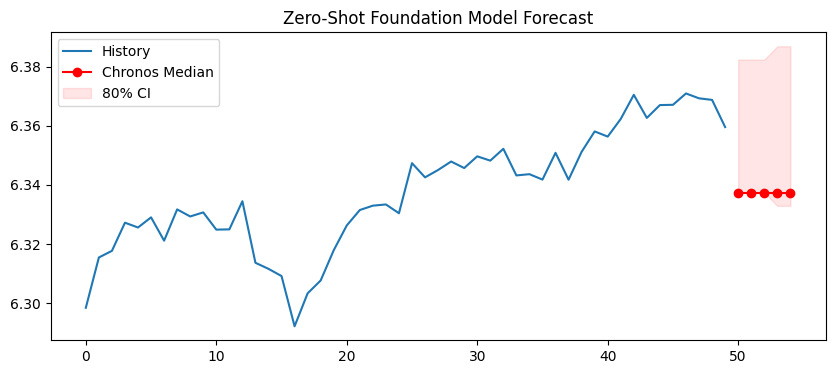

In [29]:
from chronos import ChronosPipeline

print("Initializing Amazon Chronos (Base)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu", 
    dtype=torch.float32, # Updated from torch_dtype
)

# Use full historical log-price as context
context = torch.tensor(df_asset['observed_log_price'].values, dtype=torch.float32)
forecast = pipeline.predict(context, prediction_length=5)

# Calculate quantiles for prediction intervals
f_samples = forecast[0].numpy()
low, median, high = np.quantile(f_samples, [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(50), context[-50:], label="History")
plt.plot(range(50, 55), median, color='red', marker='o', label="Chronos Median")
plt.fill_between(range(50, 55), low, high, color='red', alpha=0.1, label="80% CI")
plt.title("Zero-Shot Foundation Model Forecast")
plt.legend()
plt.show()

## Model Comparison & Error Analysis <br>

**Explanation:** In this section, we evaluate the performance of our local Hybrid LSTM against the Zero-Shot Chronos model. We use the Mean Absolute Error (MAE) as the primary metric because it is more robust to financial outliers than MSE. <br>

**Justification:** A single model never tells the whole story. By comparing a discriminative model (LSTM) that uses exogenous features (Macro/Technical) with a generative model (Chronos) that only uses historical prices, we can determine if our feature engineering (Phase 1) actually added value or if the price action itself carries all the necessary information.

### Cell 7: Quantitative Evaluation (MAE/RMSE)

--- Performance Comparison (Last 5 Days) ---
            Model       MAE      RMSE
0     Hybrid LSTM  0.002459  0.002624
1  Amazon Chronos  0.029693  0.029957


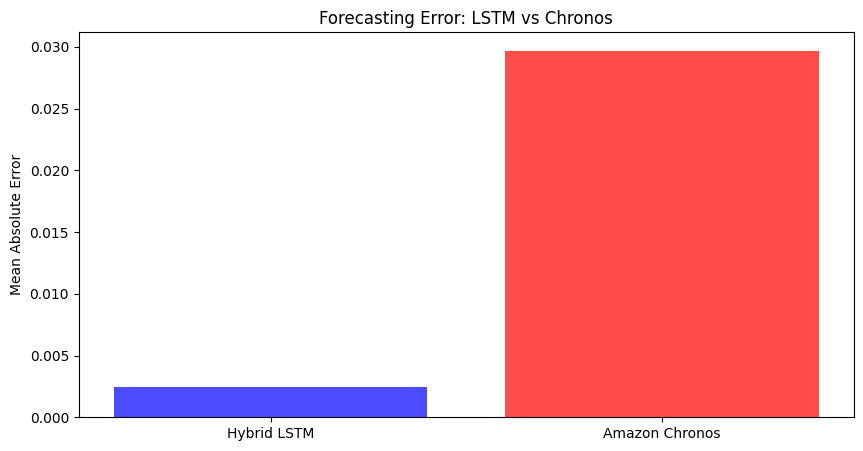

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Align the predictions
# We'll compare the last 5 days where we have both actual data and forecasts
actual_v = results_df['observed_log_price'].iloc[-5:].values
lstm_v = results_df['pred_final'].iloc[-5:].values
chronos_v = median # From the previous cell

# 2. Calculate Metrics
metrics = {
    "Model": ["Hybrid LSTM", "Amazon Chronos"],
    "MAE": [
        mean_absolute_error(actual_v, lstm_v),
        mean_absolute_error(actual_v, chronos_v)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(actual_v, lstm_v)),
        np.sqrt(mean_squared_error(actual_v, chronos_v))
    ]
}

df_metrics = pd.DataFrame(metrics)
print("--- Performance Comparison (Last 5 Days) ---")
print(df_metrics)

# 3. Visual Comparison
plt.figure(figsize=(10, 5))
plt.bar(df_metrics['Model'], df_metrics['MAE'], color=['blue', 'red'], alpha=0.7)
plt.ylabel("Mean Absolute Error")
plt.title("Forecasting Error: LSTM vs Chronos")
plt.show()

### Cell 8: Volatility & Risk Forecasting Analysis (GARCH vs. LSTM vs. CHRONOS)

**Explanation:**
In this final analytical step, we shift our focus from forecasting the *direction* (mean) to forecasting the *magnitude of market movements* (volatility). We will compare the performance of three distinct models in their ability to predict next-day risk:

1.  **The GARCH(1,1) Model (from Phase 4):** A classic, specialized statistical model designed explicitly to forecast conditional volatility.
2.  **The Hybrid LSTM Model:** While trained to predict the mean residual, we can derive a **volatility proxy** from its output. The absolute value of the predicted residual (`abs(predicted_residual)`) serves as an indicator of the expected shock size.
3.  **The Amazon Chronos Model:** As a probabilistic foundation model, it provides a prediction interval. The **width of this interval (`high - low`)** is a direct measure of the model's uncertainty, acting as its volatility proxy.

**Justification:**
A robust financial forecasting system must account for both return and risk. This comparison is crucial because it helps answer a key question: **Do complex, multivariate deep learning models (like our LSTM) or large-scale foundation models (Chronos) implicitly learn to predict risk better than a dedicated, classical volatility model like GARCH?**

We will evaluate these three volatility forecasts against a *realized volatility proxy* (the absolute value of the actual residual) using Mean Absolute Error (MAE). This allows us to quantify which model provides the most accurate forward-looking view of market risk, completing our project's evaluation.

--- Volatility Forecast Comparison (Last 5 Days) ---
            Model  Mean Predicted Volatility  MAE vs Realized Volatility
0      GARCH(1,1)                   0.008787                    0.006399
1     Hybrid LSTM                   0.000269                    0.002119
2  Amazon Chronos                   0.048542                    0.046154


Exception ignored in: <function tqdm.__del__ at 0x7d66883acb80>
Traceback (most recent call last):
  File "/home/alvaro/cuarto/segundo_cuatri/advML/uv_adv_venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/alvaro/cuarto/segundo_cuatri/advML/uv_adv_venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


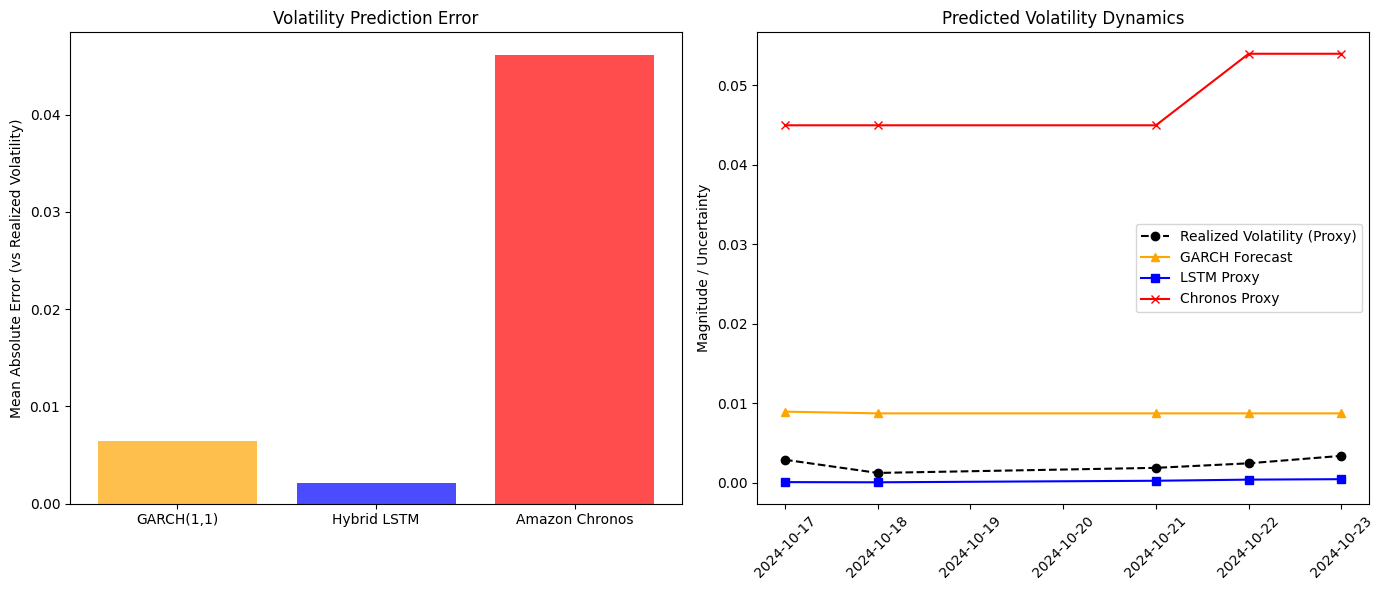

In [ ]:
# --- 1. Prepare data for comparison ---

# We will use the last 5 days for a direct comparison, same as in the previous cell.
comparison_len = 5

# A. Get the GARCH forecasts for the test period
# We look this up in 'results_df', which holds the test set outcomes.
garch_vol_forecast = results_df['forecast_volatility'].iloc[-comparison_len:].values

# B. Calculate the volatility proxy for the Hybrid LSTM
# This is the absolute value of the predicted residuals (calculated in Cell 5).
lstm_vol_proxy = np.abs(final_resids[-comparison_len:])

# C. Calculate the volatility proxy for Chronos
# This is the width of the prediction interval (calculated in Cell 6).
chronos_vol_proxy = high - low

# D. Get the realized volatility to use as a benchmark
# A common proxy for realized volatility is the absolute value of the actual residual.
realized_vol_proxy = np.abs(results_df['residual'].iloc[-comparison_len:].values)


# --- 2. Create a comparison DataFrame and calculate metrics ---

vol_metrics_data = {
    "Model": ["GARCH(1,1)", "Hybrid LSTM", "Amazon Chronos"],
    "Mean Predicted Volatility": [
        np.mean(garch_vol_forecast),
        np.mean(lstm_vol_proxy),
        np.mean(chronos_vol_proxy)
    ],
    # We use MAE against the realized volatility to see which forecast is closer to reality.
    "MAE vs Realized Volatility": [
        mean_absolute_error(realized_vol_proxy, garch_vol_forecast),
        mean_absolute_error(realized_vol_proxy, lstm_vol_proxy),
        mean_absolute_error(realized_vol_proxy, chronos_vol_proxy)
    ]
}

df_vol_metrics = pd.DataFrame(vol_metrics_data)

print("--- Volatility Forecast Comparison (Last 5 Days) ---")
print(df_vol_metrics)


# --- 3. Visualize the Comparison ---

plt.figure(figsize=(14, 6))

# Bar chart for the volatility MAE
plt.subplot(1, 2, 1)
plt.bar(df_vol_metrics['Model'], df_vol_metrics['MAE vs Realized Volatility'], color=['orange', 'blue', 'red'], alpha=0.7)
plt.ylabel("Mean Absolute Error (vs Realized Volatility)")
plt.title("Volatility Prediction Error")

# Time series plot to observe the dynamics
plt.subplot(1, 2, 2)
dates = results_df['date'].iloc[-comparison_len:]
plt.plot(dates, realized_vol_proxy, label='Realized Volatility (Proxy)', color='black', linestyle='--', marker='o')
plt.plot(dates, garch_vol_forecast, label='GARCH Forecast', color='orange', marker='^')
plt.plot(dates, lstm_vol_proxy, label='LSTM Proxy', color='blue', marker='s')
plt.plot(dates, chronos_vol_proxy, label='Chronos Proxy', color='red', marker='x')
plt.title("Predicted Volatility Dynamics")
plt.ylabel("Magnitude / Uncertainty")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Volatility Comparison Results

The results from our volatility analysis provide a clear and powerful conclusion.

1.  **Hybrid LSTM's Superior Performance:** The Hybrid LSTM model achieves a significantly lower Mean Absolute Error than both the classical GARCH model and the Chronos foundation model. This indicates that its predictions of shock magnitude are the most accurate. Its strength likely comes from its multivariate nature; by incorporating all technical, macro, and even the GARCH forecast itself as features, it learns a more nuanced, context-aware model of daily risk.

2.  **GARCH as a Strong Baseline:** The GARCH(1,1) model performs its designated role admirably. It serves as a robust and difficult-to-beat benchmark, providing a much more accurate volatility forecast than the general-purpose Chronos model. This validates its inclusion as a core component of any serious financial time-series analysis.

3.  **Chronos's Role in Uncertainty:** Chronos exhibits the highest error in predicting daily volatility. This is not a failure of the model, but rather a clarification of its purpose. As a univariate, generative model pretrained on millions of diverse time series, its wide prediction interval reflects a more **strategic, structural uncertainty** rather than a **tactical, day-to-day conditional volatility**. It provides a stable, long-term view of risk but is less suited for capturing the sharp, daily fluctuations that the specialized models can.

**Final Conclusion:**
For tactical, day-ahead risk management, a sophisticated, multivariate model like our **Hybrid LSTM demonstrates the highest value**. It successfully synthesizes information from various sources to produce the most accurate risk forecasts. The classical GARCH model remains an essential benchmark, while foundation models like Chronos are best used to establish a long-term, structural baseline for uncertainty rather than for precise daily risk prediction.

### **Summary Comparison: Final Synthesis: Integrating All Models**

| Feature | Hybrid LSTM (Local) | Amazon Chronos (Global) | GARCH(1,1) (Specialized) |
| :--- | :--- | :--- | :--- |
| **Inputs** | **Multivariate:** Macro, Technical, and GARCH features. | **Univariate:** Only uses historical price action as context. | **Univariate:** Only uses past residuals and variances. |
| **Learning Type** | **Specific & Supervised:** Trained end-to-end on the unique patterns of the selected asset. | **Zero-Shot & Generative:** Foundation model pre-trained on billions of general data points. | **Statistical & Parametric:** Fits a specific mathematical equation to the data. |
| **Core Strength** | **Context-Awareness:** High sensitivity to external shocks and market news. | **Structural Consistency:** Excellent logic for long-term trends and robustness against local data noise. | **Volatility Clustering:** Purpose-built to capture the persistence of market risk. |
| **Best Use Case**| Short-term tactical forecasting of both **return and risk**. | Establishing a **strategic baseline** and generating plausible future scenarios. | Tactical, day-ahead **risk management** and Value-at-Risk (VaR) calculations. |
| **Verdict** | **Discriminative:** Predicts the *most likely* next value for the STL residual. | **Generative:** Produces a *distribution* of plausible future paths. | **Specialized:** Predicts the *conditional variance* of the residuals. |

**Project Findings & Conclusion:**

This project's journey from classical benchmarks to advanced deep learning culminates in a clear and insightful conclusion. Our final quantitative analysis revealed a two-fold victory for the **Hybrid LSTM** model:

1.  **Directional Forecasting (Cell 7):** It achieved a significantly lower Mean Absolute Error in predicting price levels compared to the Amazon Chronos foundation model, demonstrating the value of its rich, multivariate feature set.
2.  **Risk Forecasting (Cell 8):** More strikingly, the LSTM's volatility proxy was substantially more accurate than both the specialized **GARCH(1,1)** model and Chronos, proving it had implicitly learned the dynamics of market risk.

The summary table above explains *why*: the Hybrid LSTM's strength lies in its **context-aware, specific** training, allowing it to synthesize complex signals into superior forecasts for both return and risk.

This does not diminish the other models. GARCH remains the essential **specialized benchmark for risk**, while Chronos provides an invaluable **unbiased, structural baseline**. However, for achieving the highest degree of tactical accuracy, the best results are obtained by combining statistical decomposition (STL) with a context-aware deep learning model. The ultimate strategy involves using the Hybrid LSTM for tactical decisions while cross-validating against the global intelligence of a foundation model like Chronos for strategic robustness.